# Representation Learning: Visualizing How Neural Networks Learn Features

---

## Project Overview

This experiment visualizes how neural networks transform data across layers.

Instead of treating the model as a black box , the goal is to explicitly extract and analyze how hidden layers transform raw input into structured representations that make learning possible.

---

## Core Question:

How does a neural network convert non-linearly seperable data into seperable representations?


---

## Hypothesis

- Raw input data is not linearly separable
- Hidden layers transform data into separable representations
- Final layer produce near-linear seperability

---

## Strategy

I will:

1. Visualize raw input space
2. Capture hidden layer activations.
3. Reduce dimensions using PCA
4. Compare transformations across layers
5. Overlay decision boundaries

## Tools & Justification

- NumPy / PyTorch → neural network implementation  
- Matplotlib → visualization  
- PCA → dimensionality reduction for visualization

### NOTE: PCA is used only for visualization, the actual learned representation exists in higher-dimensional space

## Experimental Setup

### Dataset

We use a **non-linearly separable dataset (circles)**:
- Ideal for demonstrating representation learning

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim

# Generate dataset
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5)
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y.reshape(-1,1), dtype=torch.float32)

## Raw Input Space (Ground Reality)

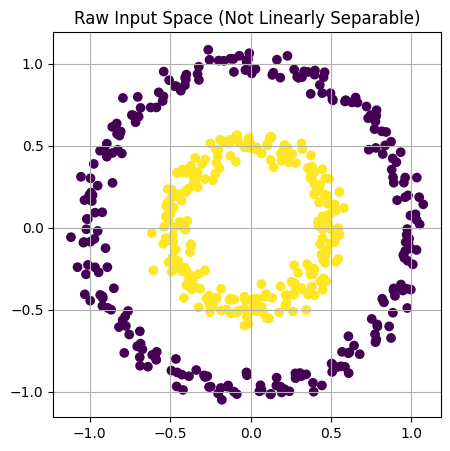

In [9]:
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Raw Input Space (Not Linearly Separable)")
plt.grid()
plt.show()

## Model Architecture:

We use a small neural network:

Input → Hidden Layer → Hidden Layer → Output

We will extract activations from hidden layers to observe transformation.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        h1 = torch.relu(self.fc1(x))
        h2 = torch.relu(self.fc2(h1))
        out = torch.sigmoid(self.fc3(h2))
        return out, h1, h2

model = Net()

## Training

In [11]:
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y.reshape(-1,1), dtype=torch.float32)

optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

for epoch in range(300):
    optimizer.zero_grad()
    out, _, _ = model(X_t)
    loss = loss_fn(out, y_t)
    loss.backward()
    optimizer.step()

# Experiments

## Experiment 1 — Raw Input Space

### Hypothesis
The dataset is not linearly separable in its original form.

### Procedure
We visualize the dataset in its original 2D space without any transformation.

### Observation
- Points from different classes are interwoven
- No linear boundary can separate them
- This motivates the need for representation learning

## Experiment 2 — Hidden Layer Transformation

##  Layer-wise Representation Transformation

### Hypothesis
Hidden layers progressively transform data into a more structured and separable space.

### Procedure
- Pass input through the trained network
- Extract activations from:
  - Hidden Layer 1
  - Hidden Layer 2
- Reduce dimensions using PCA for visualization
- Compare representations side-by-side

In [13]:
with torch.no_grad():
    _, h1, _ = model(X_t)
    _, h2, _ = model(X_t)

h1_np = h1.numpy()
h2_np = h2.numpy()

pca = PCA(n_components=2)
h1_2d = pca.fit_transform(h1_np)
h2_2d = pca.fit_transform(h2_np)

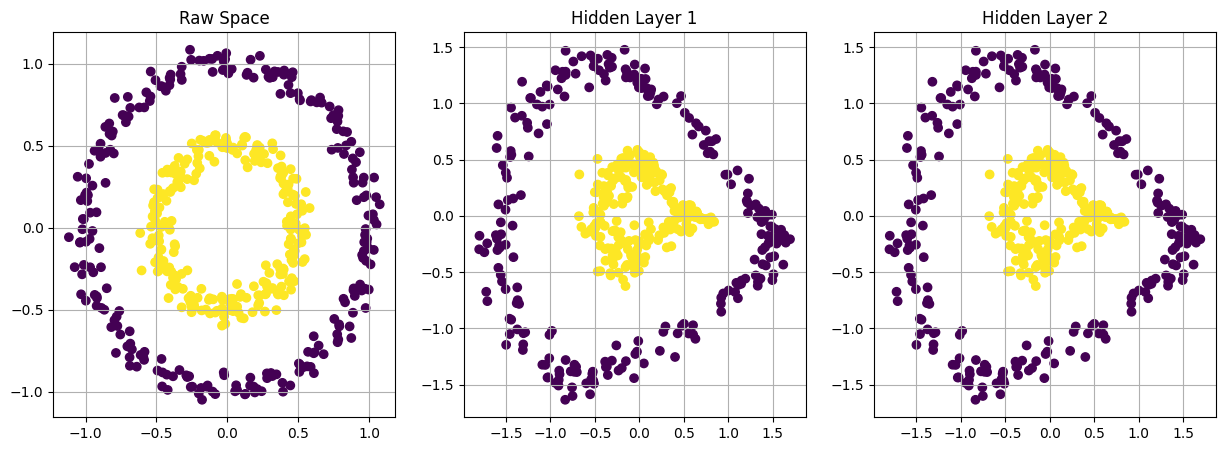

In [14]:
# Visualization

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Raw
axes[0].scatter(X[:,0], X[:,1], c=y)
axes[0].set_title("Raw Space")

# Layer 1
axes[1].scatter(h1_2d[:,0], h1_2d[:,1], c=y)
axes[1].set_title("Hidden Layer 1")

# Layer 2
axes[2].scatter(h2_2d[:,0], h2_2d[:,1], c=y)
axes[2].set_title("Hidden Layer 2")

for ax in axes:
    ax.grid()

plt.show()

### Observation

- Raw Space:
  - Data is circular and entangled

- Hidden Layer 1:
  - Data begins to spread and partially organize
  - Early structure emerges

- Hidden Layer 2:
  - Clear clustering forms
  - Classes become more separable

Conclusion:
The network is progressively reshaping the data distribution.   

This Confirms the Hypothesis


## Experiment 3 — Decision Boundary Learning

### Hypothesis
If the network has learned meaningful representations, it should produce a non-linear decision boundary that separates the classes.

### Procedure
- Generate a dense grid over input space
- Pass grid points through the model
- Visualize predicted probabilities as a contour plot

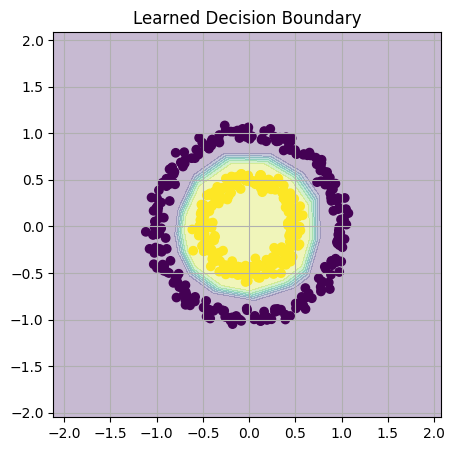

In [15]:
def plot_boundary(model, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        preds, _, _ = model(grid)

    Z = preds.reshape(xx.shape)

    plt.figure(figsize=(5,5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(title)
    plt.grid()
    plt.show()

plot_boundary(model, "Learned Decision Boundary")

### Observation

- The model learns a circular boundary
- This matches the underlying structure of the data
- Indicates successful transformation of feature space

Conclusion:
The network has learned a non-linear mapping aligned with the data geometry.

THIS CONFIRMS THE HYPOTHESIS

# Experiment 4 — Geometry Insight (Distance Shift)



### Hypothesis
The network increases separation between classes by transforming distances in feature space.

### Procedure
- Compute average pairwise distance in:
  - Raw input space
  - Final hidden layer space
- Compare the two

In [16]:
# Distance comparison
from scipy.spatial.distance import pdist

raw_dist = np.mean(pdist(X))
h2_dist = np.mean(pdist(h2))

print("Avg distance in raw space:", raw_dist)
print("Avg distance in learned space:", h2_dist)

Avg distance in raw space: 1.012253235840634
Avg distance in learned space: 1.6439090276826478


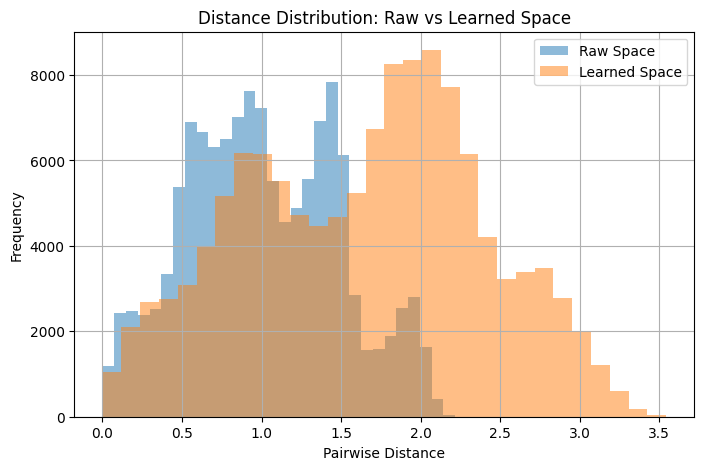

In [18]:
# ===== DISTANCE COMPARISON VISUALIZATION =====

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# Raw space distances
raw_distances = pdist(X)

# Learned space distances (use final hidden layer h2)
learned_distances = pdist(h2)

plt.figure(figsize=(8,5))

plt.hist(raw_distances, bins=30, alpha=0.5, label="Raw Space")
plt.hist(learned_distances, bins=30, alpha=0.5, label="Learned Space")

plt.title("Distance Distribution: Raw vs Learned Space")
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

### Observation

- Average distance increases significantly in learned space
- Indicates expansion of feature space
- Classes become more distinguishable

Conclusion:
The network reshapes the geometry of the data to improve separability.

In [ ]:
# Class-wise centroids (hidden space)
import numpy as np

class0 = h2[y == 0]
class1 = h2[y == 1]

centroid_dist = np.linalg.norm(class0.mean(axis=0) - class1.mean(axis=0))

print("Distance between class centroids:", centroid_dist)

Distance between class centroids: 4.6071644


Observation:
- Class centroids are far apart in learned space
- Confirms improved separability

# Failure Analysis

- Raw inputs lack seperability
- Hidden layers create structure required for classification
- Network progressively warps space

# Key Insights

- Neural networks are geometric transformers
- Learning = reshaping data manifolds   
- Separability is created not given
- Depth enables complex transformations  

# Future Work

- Animate transformations across epochs
- Compare shallow vs deep networks
- Try different activations
- Visualize 3D embeddings